# Combined Allocation Model

## Objective

Combine:

1. Factor Strength Timing
2. Market Stretch Timing

into a single dynamic allocation framework.

Hypothesis:

Strong factor environments and oversold market conditions may jointly improve portfolio performance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

print(close.shape)

(2716, 332)


In [3]:
mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

rebalance_dates = close.index[
    126::42
]

print(
    len(rebalance_dates)
)

62


In [4]:
factor_strength = []

for date in rebalance_dates[:-1]:

    scores = (
        mom126.loc[date]
        .dropna()
    )

    top20 = (
        scores
        .nlargest(20)
        .mean()
    )

    bottom20 = (
        scores
        .nsmallest(20)
        .mean()
    )

    spread = (
        top20
        -
        bottom20
    )

    factor_strength.append(
        spread
    )

factor_strength = pd.Series(
    factor_strength,
    index=rebalance_dates[:-1]
)

factor_strength.head()

Date
2015-07-07         NaN
2015-09-03    1.245608
2015-11-06    1.191643
2016-01-11    1.149759
2016-03-11    0.847404
dtype: float64

In [5]:
market = close.mean(
    axis=1
)

market_index = (
    market
    /
    market.iloc[0]
)

ma252 = (
    market_index
    .rolling(252)
    .mean()
)

stretch = (
    market_index
    /
    ma252
    -
    1
)

stretch.head()

Date
2015-01-01   NaN
2015-01-02   NaN
2015-01-05   NaN
2015-01-06   NaN
2015-01-07   NaN
dtype: float64

In [6]:
factor_rank = (
    factor_strength
    .rank(pct=True)
)

exposure = (
    2.0
    *
    factor_rank
)

print(
    "Average Exposure:",
    round(
        exposure.mean(),
        3
    )
)

print(
    "Min Exposure:",
    round(
        exposure.min(),
        3
    )
)

print(
    "Max Exposure:",
    round(
        exposure.max(),
        3
    )
)

Average Exposure: 1.017
Min Exposure: 0.033
Max Exposure: 2.0


In [7]:
stretch_rank = (
    1
    -
    stretch.rank(
        pct=True
    )
)

market_exposure = (
    0.75
    +
    0.50
    *
    stretch_rank
)

market_exposure.describe()

count    2465.000000
mean        0.999899
std         0.144367
min         0.750000
25%         0.874949
50%         0.999899
75%         1.124848
max         1.249797
dtype: float64

## Allocation Signals

Factor Signal:

Derived from Momentum126 Factor Strength.

Market Signal:

Derived from Market Stretch.

Final Exposure:

Factor Exposure × Market Exposure

In [8]:
combined = pd.DataFrame(
    index=factor_strength.index
)

combined["Factor"] = (
    exposure
)

combined["Market"] = (
    market_exposure
    .reindex(
        factor_strength.index,
        method="ffill"
    )
)

combined["Exposure"] = (
    combined["Factor"]
    *
    combined["Market"]
)

combined.describe()

,Factor,Market,Exposure
count,60.000000,58.000000,58.000000
mean,1.016667,1.005232,0.960263
std,0.582142,0.140524,0.503583
min,0.033333,0.753245,0.041471
25%,0.525000,0.882657,0.539929
50%,1.016667,1.017546,0.990693
75%,1.508333,1.132049,1.430334
max,2.000000,1.244118,1.962478


In [9]:
def metrics(returns):

    equity = (
        1 + returns
    ).cumprod()

    total_return = (
        equity.iloc[-1]
        -
        1
    )

    years = (
        len(close)
        /
        252
    )

    cagr = (
        equity.iloc[-1]
        **
        (1 / years)
        -
        1
    )

    sharpe = (
        returns.mean()
        /
        returns.std()
    ) * np.sqrt(
        252 / 42
    )

    max_dd = (
        equity
        /
        equity.cummax()
        -
        1
    ).min()

    win_rate = (
        returns > 0
    ).mean()

    profit_factor = (
        returns[
            returns > 0
        ].sum()
        /
        abs(
            returns[
                returns < 0
            ].sum()
        )
    )

    return {
        "Total Return":
            total_return,
        "CAGR":
            cagr,
        "Sharpe":
            sharpe,
        "MaxDD":
            max_dd,
        "Win Rate":
            win_rate,
        "Profit Factor":
            profit_factor
    }

In [10]:
baseline_returns = []

previous_portfolio = None

for i in range(
    len(rebalance_dates)-1
):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
    )

    selected = (
        scores
        .nlargest(20)
        .index
    )

    gross_return = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        -
        1
    ).mean()

    turnover = 1

    if previous_portfolio is not None:

        overlap = len(
            set(selected)
            &
            previous_portfolio
        )

        turnover = (
            20
            -
            overlap
        ) / 20

    net_return = (
        gross_return
        -
        turnover
        *
        0.001
    )

    baseline_returns.append(
        net_return
    )

    previous_portfolio = (
        set(selected)
    )

baseline_returns = pd.Series(
    baseline_returns,
    index=rebalance_dates[:-1]
)

In [11]:
factor_returns = []

previous_portfolio = None

for i in range(
    len(rebalance_dates)-1
):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
    )

    selected = (
        scores
        .nlargest(20)
        .index
    )

    gross_return = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    turnover = 1

    if previous_portfolio is not None:

        overlap = len(
            set(selected)
            &
            previous_portfolio
        )

        turnover = (
            20 - overlap
        ) / 20

    position_size = exposure.loc[start]

    net_return = (
        position_size
        *
        gross_return
        -
        turnover * 0.001
    )

    factor_returns.append(
        net_return
    )

    previous_portfolio = set(
        selected
    )

factor_returns = pd.Series(
    factor_returns,
    index=rebalance_dates[:-1]
)

In [12]:
combined_returns = []

previous_portfolio = None

for i in range(
    len(rebalance_dates)-1
):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
    )

    selected = (
        scores
        .nlargest(20)
        .index
    )

    gross_return = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        -
        1
    ).mean()

    turnover = 1

    if previous_portfolio is not None:

        overlap = len(
            set(selected)
            &
            previous_portfolio
        )

        turnover = (
            20
            -
            overlap
        ) / 20

    net_return = (
        combined.loc[
            start,
            "Exposure"
        ]
        *
        gross_return
        -
        turnover
        *
        0.001
    )

    combined_returns.append(
        net_return
    )

    previous_portfolio = (
        set(selected)
    )

combined_returns = pd.Series(
    combined_returns,
    index=rebalance_dates[:-1]
)

## Strategy Comparison

Three strategies are evaluated:

1. Baseline Momentum126
2. Factor Allocation
3. Combined Allocation

Performance is compared using CAGR, Sharpe Ratio, Max Drawdown, Win Rate, and Profit Factor.

In [13]:
comparison = pd.DataFrame({

    "Baseline":
        metrics(
            baseline_returns
        ),

    "Factor Allocation":
        metrics(
            factor_returns
        ),

    "Combined Allocation":
        metrics(
            combined_returns
        )

}).T

comparison.to_csv(
    "../results/tables/10_combined_model_results.csv"
)

comparison

,Total Return,CAGR,Sharpe,MaxDD,Win Rate,Profit Factor
Baseline,37.708294,0.403854,1.377718,-0.284502,0.721311,4.019300
Factor Allocation,81.235007,0.505517,1.287932,-0.367619,0.721311,5.044650
Combined Allocation,52.597561,0.446892,1.292195,-0.303989,0.688525,4.711479


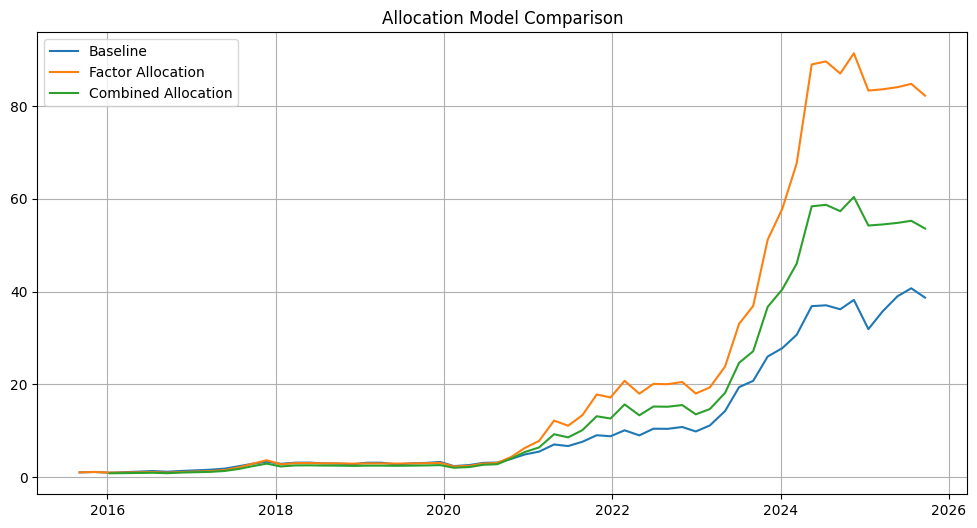

In [14]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    (1+baseline_returns).cumprod(),
    label="Baseline"
)

plt.plot(
    (1+factor_returns).cumprod(),
    label="Factor Allocation"
)

plt.plot(
    (1+combined_returns).cumprod(),
    label="Combined Allocation"
)

plt.title(
    "Allocation Model Comparison"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/plots/10_strategy_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Conclusion

Factor Allocation successfully improved portfolio performance.

Market Stretch exhibited predictive information in isolation but reduced performance when combined with the momentum allocation model.

Final Outcome:

Best Strategy:

Momentum126
+
Dynamic Factor Allocation

The addition of Market Stretch did not improve results and was therefore excluded from the final strategy specification.